<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#a5b4fc 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 205 &middot; Reflection &amp; Next Steps</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">The Analyst's Toolkit</div>
  <div style="font-size:15px;color:#c7d2fe;max-width:820px;line-height:1.6">Nine functions that do the things every project needs doing: look at the data, find the gaps that are not blank, check the assumptions before the test, choose the test, judge the model, and backtest a forecast. Written to be copied out of here and kept.</div>
</div>

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
plt.rcParams.update({"figure.dpi":110,"font.size":10.5,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":11.5,"axes.titlelocation":"left"})
IN, DK, LT, MUT, GD, RD = "#4338ca", "#1e1b4b", "#a5b4fc", "#94a3b8", "#047857", "#dc2626"
print("toolkit ready")

toolkit ready


## 1 &middot; A messy example to work on

Everything below is dataset-agnostic. The example is generated here so the notebook is self-contained
and the functions can be lifted straight out.

In [2]:
rng = np.random.default_rng(2050)
n = 900
age    = np.clip(rng.normal(44, 13, n), 18, 85).round(0)
region = rng.choice(["North","South","East","West"], n, p=[.3,.28,.22,.20])
tenure = np.clip(rng.gamma(2.0, 14, n), 0, None).round(0)
spend  = np.round(np.exp(rng.normal(np.log(180), 0.55, n)) + 2.1*tenure + 1.4*(age-44), 2)
lp     = -0.4 - 0.055*tenure + 0.0075*(spend-250) + 0.020*(age-44)
churn  = (rng.random(n) < 1/(1+np.exp(-lp))).astype(int)

D = pd.DataFrame(dict(cust_id=[f"C{5000+i}" for i in range(n)], age=age, region=region,
                      tenure_months=tenure, spend=spend, churned=churn))
# the usual damage
D.loc[rng.choice(n, 40, replace=False), "age"] = -1                 # a sentinel
D.loc[rng.choice(n, 25, replace=False), "spend"] = np.nan           # honest blanks
D.loc[rng.choice(n, 12, replace=False), "tenure_months"] = 9999     # another sentinel
D.loc[rng.choice(n, 18, replace=False), "region"] = "north"         # case drift
D = pd.concat([D, D.iloc[rng.choice(n, 15, replace=False)]], ignore_index=True)   # duplicates
print(f"{len(D)} rows, {D.shape[1]} columns")
D.head(3)

915 rows, 6 columns


,cust_id,age,region,tenure_months,spend,churned
0,C5000,18.0,South,29.0,151.49,0
1,C5001,47.0,South,64.0,334.17,0
2,C5002,37.0,North,23.0,152.97,0


## 2 &middot; `first_look` &mdash; the ten minutes before anything else

In [3]:
def first_look(df, key=None, max_card=12):
    """Shape, types, duplicates, missingness including disguised missingness, and a numeric summary."""
    print(f"SHAPE           {df.shape[0]:,} rows x {df.shape[1]} columns")
    if key is not None:
        d = df.duplicated(key).sum()
        print(f"DUPLICATE {key:<10} {d}" + ("  <- resolve before anything else" if d else ""))
    print(f"EXACT DUPES     {df.duplicated().sum()}")

    rows = []
    for c in df.columns:
        s = df[c]
        blank = s.isna().mean()
        sus = ""
        if pd.api.types.is_numeric_dtype(s):
            for sent in (-1, -999, 999, 9999, -9999, 99999):
                if (s == sent).sum() > 0: sus += f" {sent}x{(s==sent).sum()}"
        else:
            odd = {v for v in s.dropna().unique() if isinstance(v, str)
                   and v.strip().lower() in {"na","n/a","none","null","unknown","-","?",""}}
            if odd: sus = " " + ",".join(sorted(odd))
        rows.append([c, str(s.dtype), f"{blank:.1%}", s.nunique(), sus.strip()])
    print()
    print(pd.DataFrame(rows, columns=["column","dtype","blank","distinct","suspicious values"]
                       ).to_string(index=False))

    num = df.select_dtypes("number")
    if len(num.columns):
        print()
        q = num.describe(percentiles=[.01,.25,.5,.75,.99]).T
        q["skew"] = num.skew()
        print(q[["count","mean","std","1%","50%","99%","max","skew"]].round(2).to_string())

    cats = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])
            and df[c].nunique() <= max_card]
    for c in cats:
        print(f"\n{c}: " + ", ".join(f"{k} {v}" for k, v in df[c].value_counts().items()))

first_look(D, key="cust_id")

SHAPE           915 rows x 6 columns
DUPLICATE cust_id    15  <- resolve before anything else
EXACT DUPES     15

       column   dtype blank  distinct suspicious values
      cust_id  object  0.0%       900                  
          age float64  0.0%        63             -1x40
       region  object  0.0%         5                  
tenure_months float64  0.0%        92           9999x12
        spend float64  2.8%       864                  
      churned   int64  0.0%         2                  

               count    mean      std     1%     50%      99%     max  skew
age            915.0   42.64    15.47  -1.00   44.00    74.86    85.0 -0.71
tenure_months  915.0  157.64  1135.28   3.00   22.00  9999.00  9999.0  8.57
spend          889.0  275.24   135.62  82.28  247.05   728.29   988.2  1.56
churned        915.0    0.21     0.41   0.00    0.00     1.00     1.0  1.45

region: South 257, North 249, West 207, East 184, north 18


**Read the `suspicious values` column first.** A `-1` age and a `9999` tenure are not missing as far as
pandas is concerned. They will average, they will regress, and nothing will warn you. In
[Chapter 202](../../capstone-missing-data-imputation.html) that difference was twenty-one points of a survey.

**Then read `distinct` against `dtype`.** A numeric column read as `object` has a string in it somewhere. A
categorical column with more levels than you expected has a spelling problem, which `north` against `North`
is here.

## 3 &middot; `clean_report` &mdash; make the repairs explicit

In [4]:
def clean_report(df, sentinels=None, key=None, ranges=None):
    """Apply and PRINT every repair. A cleaning step nobody can see is a cleaning step nobody can check."""
    d = df.copy(); log = []
    if key is not None:
        b = len(d); d = d.drop_duplicates(key)
        if len(d) < b: log.append(f"dropped {b-len(d)} duplicate {key}")
    for col, vals in (sentinels or {}).items():
        for v in vals:
            k = (d[col] == v).sum()
            if k: d.loc[d[col] == v, col] = np.nan; log.append(f"{col}: {k} rows of {v} -> missing")
    for col, (lo, hi) in (ranges or {}).items():
        bad = (~d[col].between(lo, hi)) & d[col].notna()
        if bad.sum(): d.loc[bad, col] = np.nan; log.append(f"{col}: {bad.sum()} outside [{lo}, {hi}] -> missing")
    for c in d.columns:
        if d[c].dtype == object and d[c].dropna().map(lambda v: isinstance(v, str)).all():
            before = d[c].nunique(); d[c] = d[c].str.strip().str.title()
            if d[c].nunique() < before: log.append(f"{c}: {before} spellings -> {d[c].nunique()}")
    for line in log: print("  " + line)
    print(f"\n  {len(df)} rows in, {len(d)} rows out, "
          f"{d.isna().any(axis=1).mean():.1%} now carry a gap somewhere")
    return d

C1 = clean_report(D, key="cust_id",
                  sentinels={"age": [-1], "tenure_months": [9999]},
                  ranges={"age": (18, 110), "spend": (0, 1e6)})

  dropped 15 duplicate cust_id
  age: 40 rows of -1 -> missing
  tenure_months: 12 rows of 9999 -> missing
  region: 5 spellings -> 4

  915 rows in, 900 rows out, 8.1% now carry a gap somewhere


**Every repair is a decision and every decision gets printed.** Six months later the only question anyone
will ask about this dataset is what you did to it, and the answer should be in the output rather than in
your memory. See [Chapter 18](../../the-data-cleaning-mindset.html).

## 4 &middot; `describe_plus` &mdash; a summary that admits when it is lying

In [5]:
def describe_plus(s, name=None):
    """Center, spread, shape, and a warning when the mean is not a fair summary."""
    s = pd.Series(s).dropna(); name = name or (s.name or "series")
    sk, ku = float(stats.skew(s)), float(stats.kurtosis(s, fisher=True))
    iqr = s.quantile(.75) - s.quantile(.25)
    out = {"n": len(s), "mean": s.mean(), "median": s.median(), "sd": s.std(),
           "IQR": iqr, "skew": sk, "excess kurtosis": ku,
           "CV": s.std()/s.mean() if s.mean() else np.nan}
    print(f"--- {name} ---")
    for k, v in out.items(): print(f"  {k:16s} {v:12,.3f}")
    notes = []
    if abs(sk) > 1:      notes.append(f"strongly skewed ({sk:+.2f}); quote the median, not the mean")
    elif abs(sk) > 0.5:  notes.append(f"moderately skewed ({sk:+.2f})")
    if ku > 3:           notes.append(f"heavy tails (excess kurtosis {ku:.1f}); the SD understates the risk")
    lo, hi = s.quantile(.25)-1.5*iqr, s.quantile(.75)+1.5*iqr
    k = int(((s < lo) | (s > hi)).sum())
    if k: notes.append(f"{k} points ({k/len(s):.1%}) outside the 1.5 IQR fence")
    if s.min() >= 0 and sk > 1: notes.append("non-negative and right-skewed: a log scale usually helps")
    for t in notes: print(f"  ! {t}")
    return out

_ = describe_plus(C1.spend, "spend")
print()
_ = describe_plus(C1.age, "age")

--- spend ---
  n                     875.000
  mean                  275.390
  median                247.200
  sd                    135.931
  IQR                   144.125
  skew                    1.561
  excess kurtosis         3.729
  CV                      0.494
  ! strongly skewed (+1.56); quote the median, not the mean
  ! heavy tails (excess kurtosis 3.7); the SD understates the risk
  ! 38 points (4.3%) outside the 1.5 IQR fence
  ! non-negative and right-skewed: a log scale usually helps

--- age ---
  n                     860.000
  mean                   44.784
  median                 45.000
  sd                     12.625
  IQR                    17.000
  skew                    0.035
  excess kurtosis        -0.216
  CV                      0.282
  ! 7 points (0.8%) outside the 1.5 IQR fence


**The mean and the median disagreeing is information, not a nuisance.** On a right-skewed spend
distribution the mean describes nobody: it sits above most of the customers and below the few who matter.
[Chapters 8 to 13](../../shape-of-a-distribution.html) are the long version.

## 5 &middot; `check_distribution` &mdash; before you assume normal

--- spend  (n = 875) ---
  Shapiro-Wilk       p = 2.11e-24  reject normality
  D'Agostino K^2     p = 4.17e-61  reject normality
  Anderson-Darling   stat  21.510  5% critical 0.751  reject
  skew +1.56   excess kurtosis +3.73
  ! n = 875: these tests reject trivial departures. Judge the Q-Q plot, not the p-value.
  ! n >= 30: the CLT means a test ABOUT THE MEAN is usually fine even if the data is not normal.


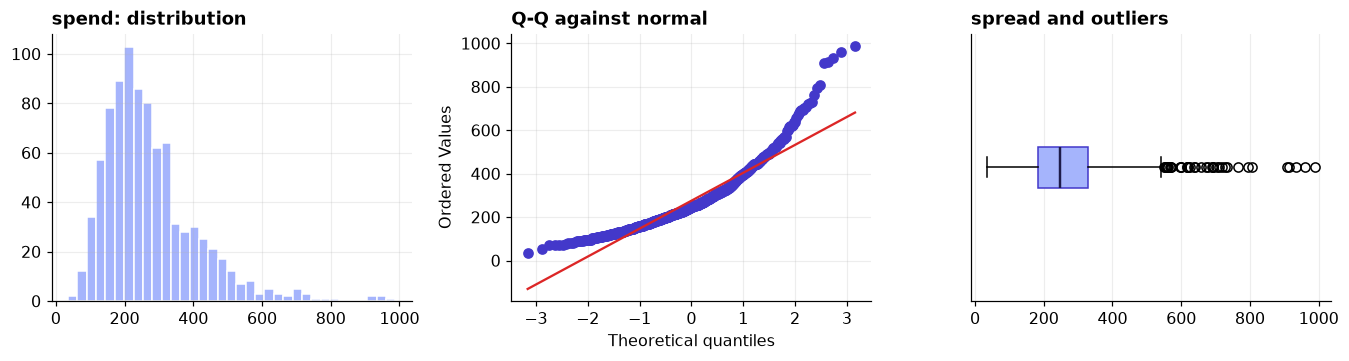

In [6]:
def check_distribution(s, name=None, alpha=0.05, plot=True):
    """Normality by test AND by eye, with the sample-size caveat stated."""
    s = pd.Series(s).dropna().to_numpy(float); name = name or "series"
    n = len(s)
    res = {}
    if n <= 5000:
        res["Shapiro-Wilk"] = stats.shapiro(s)[1]
    res["D'Agostino K^2"] = stats.normaltest(s)[1]
    res["Anderson-Darling"] = stats.anderson(s, "norm").statistic
    print(f"--- {name}  (n = {n:,}) ---")
    for k, v in res.items():
        if k.startswith("Anderson"):
            crit = stats.anderson(s, "norm").critical_values[2]
            print(f"  {k:18s} stat {v:7.3f}  5% critical {crit:.3f}  "
                  f"{'reject' if v > crit else 'do not reject'}")
        else:
            print(f"  {k:18s} p = {v:8.3g}  {'reject normality' if v < alpha else 'do not reject'}")
    print(f"  skew {stats.skew(s):+.2f}   excess kurtosis {stats.kurtosis(s):+.2f}")
    if n > 300:
        print(f"  ! n = {n:,}: these tests reject trivial departures. Judge the Q-Q plot, not the p-value.")
    if n >= 30:
        print(f"  ! n >= 30: the CLT means a test ABOUT THE MEAN is usually fine even if the data is not normal.")
    if plot:
        fig, ax = plt.subplots(1, 3, figsize=(12.4, 3.4))
        ax[0].hist(s, bins=min(40, max(10, n//25)), color=LT, edgecolor="white")
        ax[0].set_title(f"{name}: distribution")
        stats.probplot(s, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q against normal")
        ax[1].get_lines()[0].set_color(IN); ax[1].get_lines()[1].set_color(RD)
        ax[2].boxplot(s, vert=False, patch_artist=True,
                      boxprops=dict(facecolor=LT, edgecolor=IN), medianprops=dict(color=DK, lw=1.6))
        ax[2].set_yticks([]); ax[2].set_title("spread and outliers")
        plt.tight_layout(); plt.show()
    return res

_ = check_distribution(C1.spend.dropna(), "spend")

**A normality test answers a question you usually do not have.** With a large sample it rejects departures
too small to matter; with a small one it fails to detect departures that matter a lot. The Q-Q plot is the
better instrument, and the more useful question is normality *of what*: most tests about a mean rely on the
sampling distribution being normal, which the
[Central Limit Theorem](../../sampling-distributions-and-the-central-limit-theorem.html) usually supplies even
when the data is nothing like normal.

## 6 &middot; `check_model` &mdash; the regression diagnostic battery

--- diagnostics, n = 827, k = 2 ---
  homoscedasticity   Breusch-Pagan p = 0.0945  constant variance is plausible
  independence       Durbin-Watson  = 2.020  no obvious autocorrelation
  residual normality p = 4.422e-27  skew +1.86  kurtosis +5.11
  linearity          RESET p = 0.5608  (small p suggests a missing curve or interaction)
  multicollinearity  worst VIF 1.00 (tenure_months)  acceptable
  influence          37 points with Cook's D > 4/n  (max 0.044 at row 67)


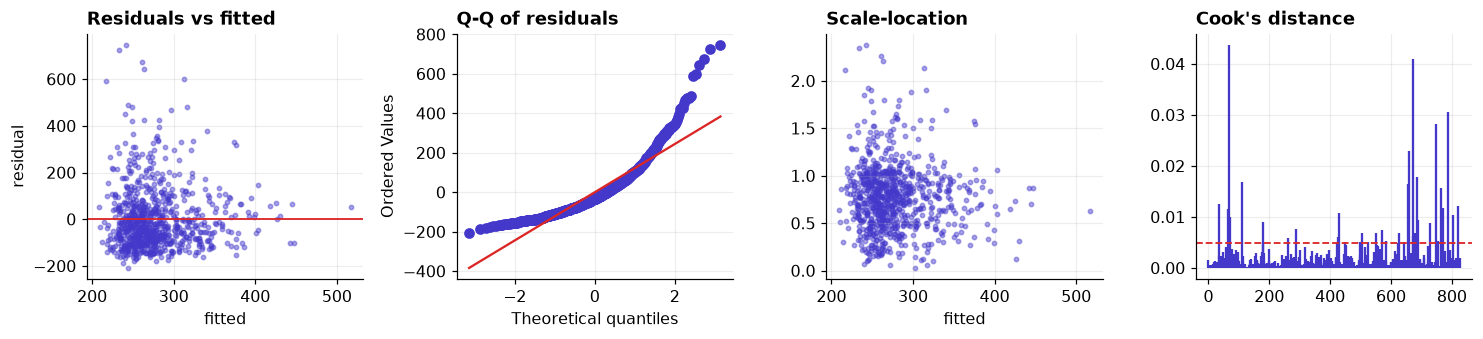

In [7]:
def check_model(model, X=None, plot=True):
    """Linearity, homoscedasticity, normality of residuals, independence, multicollinearity, influence."""
    r = model.resid; f = model.fittedvalues; n = len(r)
    print(f"--- diagnostics, n = {n:,}, k = {model.df_model:.0f} ---")

    from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
    from statsmodels.stats.stattools import durbin_watson
    bp = het_breuschpagan(r, model.model.exog)
    print(f"  homoscedasticity   Breusch-Pagan p = {bp[1]:.4f}  "
          f"{'NON-CONSTANT variance' if bp[1] < 0.05 else 'constant variance is plausible'}")
    dw = durbin_watson(r)
    print(f"  independence       Durbin-Watson  = {dw:.3f}  "
          f"{'autocorrelation' if dw < 1.5 or dw > 2.5 else 'no obvious autocorrelation'}")
    sh = stats.shapiro(r)[1] if n <= 5000 else stats.normaltest(r)[1]
    print(f"  residual normality p = {sh:.4g}  skew {stats.skew(r):+.2f}  "
          f"kurtosis {stats.kurtosis(r):+.2f}")
    try:
        print(f"  linearity          RESET p = {linear_reset(model, power=2, use_f=True).pvalue:.4f}  "
              f"(small p suggests a missing curve or interaction)")
    except Exception as e:
        print(f"  linearity          RESET unavailable ({type(e).__name__})")

    if X is not None:
        from statsmodels.stats.outliers_influence import variance_inflation_factor
        Xc = sm.add_constant(X)
        vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
                        index=Xc.columns).drop("const", errors="ignore").sort_values(ascending=False)
        print(f"  multicollinearity  worst VIF {vif.iloc[0]:.2f} ({vif.index[0]})  "
              f"{'above 10, coefficients are unstable' if vif.iloc[0] > 10 else 'acceptable'}")

    infl = model.get_influence()
    cook = infl.cooks_distance[0]
    big = int((cook > 4/n).sum())
    print(f"  influence          {big} points with Cook's D > 4/n  "
          f"(max {cook.max():.3f} at row {int(np.argmax(cook))})")

    if plot:
        fig, ax = plt.subplots(1, 4, figsize=(13.6, 3.2))
        ax[0].scatter(f, r, s=8, alpha=0.45, color=IN); ax[0].axhline(0, color=RD, lw=1.2)
        ax[0].set_xlabel("fitted"); ax[0].set_ylabel("residual"); ax[0].set_title("Residuals vs fitted")
        stats.probplot(r, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q of residuals")
        ax[1].get_lines()[0].set_color(IN); ax[1].get_lines()[1].set_color(RD)
        ax[2].scatter(f, np.sqrt(np.abs(r/r.std())), s=8, alpha=0.45, color=IN)
        ax[2].set_xlabel("fitted"); ax[2].set_title("Scale-location")
        ax[3].stem(range(n), cook, markerfmt=" ", basefmt=" ", linefmt=IN)
        ax[3].axhline(4/n, color=RD, lw=1.2, ls="--"); ax[3].set_title("Cook's distance")
        plt.tight_layout(); plt.show()

E = C1.dropna(subset=["spend","age","tenure_months"])
Xd = E[["age","tenure_months"]]
m = sm.OLS(E.spend, sm.add_constant(Xd)).fit()
check_model(m, X=Xd)

**These four checks are a sequence, not a checklist.** A curve in the residuals will also show up as
non-constant variance and as non-normal residuals, so fix the linearity first and re-run before believing the
other three. [Chapter 98](../../regression-assumptions-and-diagnostics.html) works through the order, and
[Chapter 187](../../capstone-regression-diagnostics-and-remedies.html) shows a case where each failure was
hiding the next.

**And a failed check is a signpost, not a verdict.** Non-constant variance does not invalidate the
coefficients, it invalidates the standard errors, and robust standard errors fix that in one argument.

## 7 &middot; `choose_test` &mdash; the decision, made explicit

In [8]:
def choose_test(kind, groups=None, paired=False, n=None, normal=None, equal_var=None, expected_min=None):
    """Recommend a test from the shape of the problem. Prints the reasoning, not just the answer."""
    kind = kind.lower()
    rec, why = None, []
    if kind == "means":
        if groups == 1:
            rec = "one-sample t-test" if (normal or (n or 0) >= 30) else "Wilcoxon signed-rank"
            why.append("n >= 30 lets the CLT carry the mean" if (n or 0) >= 30 else "small n and non-normal")
        elif groups == 2:
            if paired:
                rec = "paired t-test" if (normal or (n or 0) >= 30) else "Wilcoxon signed-rank"
                why.append("measurements are paired, so test the differences")
            elif normal is False and (n or 0) < 30:
                rec = "Mann-Whitney U"; why.append("small and non-normal: compare distributions, not means")
            else:
                rec = "Welch's t-test"; why.append("Welch is the default; it does not assume equal variances")
                if equal_var: why.append("equal variances would allow Student's t, but Welch costs almost nothing")
        else:
            rec = "one-way ANOVA" if (equal_var is not False) else "Welch's ANOVA"
            why.append(f"{groups} groups at once, which avoids inflating error with pairwise tests")
            why.append("follow a significant result with Tukey HSD, not with t-tests")
            if normal is False: rec = "Kruskal-Wallis"; why.append("non-normal: rank-based alternative")
    elif kind == "proportions":
        rec = "two-proportion z-test" if groups == 2 else "chi-square test of homogeneity"
        if expected_min is not None and expected_min < 5:
            rec = "Fisher's exact test"; why.append(f"smallest expected count {expected_min} < 5")
    elif kind == "association":
        rec = "chi-square test of independence"
        if expected_min is not None and expected_min < 5:
            rec = "Fisher's exact test"; why.append(f"smallest expected count {expected_min} < 5")
    elif kind == "correlation":
        rec = "Pearson r" if normal else "Spearman rho"
        why.append("Pearson measures linear association and assumes roughly normal, unbounded data"
                   if normal else "Spearman is monotone and robust to outliers and skew")
    elif kind == "variances":
        rec = "Levene's test"; why.append("Levene is far less sensitive to non-normality than Bartlett")
    print(f"RECOMMENDED  {rec}")
    for w in why: print(f"  - {w}")
    print("  - report an effect size and an interval, not only a p-value")
    return rec

choose_test("means", groups=2, n=420, normal=True)
print(); choose_test("means", groups=4, normal=False)
print(); choose_test("association", expected_min=3)

RECOMMENDED  Welch's t-test
  - Welch is the default; it does not assume equal variances
  - report an effect size and an interval, not only a p-value

RECOMMENDED  Kruskal-Wallis
  - 4 groups at once, which avoids inflating error with pairwise tests
  - follow a significant result with Tukey HSD, not with t-tests
  - non-normal: rank-based alternative
  - report an effect size and an interval, not only a p-value

RECOMMENDED  Fisher's exact test
  - smallest expected count 3 < 5
  - report an effect size and an interval, not only a p-value


"Fisher's exact test"

The function is a convenience. **The reasoning it prints is the part worth keeping**, and
[Chapter 83](../../choosing-the-right-test.html) is the full decision tree.

## 8 &middot; `evaluate_classifier` &mdash; past accuracy

In [9]:
def evaluate_classifier(y, p, thresh=None, groups=None):
    """Discrimination, calibration, the threshold decision, and disparity if a group is supplied.
    thresh=None puts the cut at the base rate, which is nearly always more useful than 0.5."""
    from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                                 confusion_matrix, precision_score, recall_score, f1_score)
    y = np.asarray(y); p = np.asarray(p, float)
    if thresh is None: thresh = float(y.mean())
    yh = (p >= thresh).astype(int)
    print(f"  threshold          {thresh:.3f}   (base rate; 0.5 would classify almost nobody as positive)")
    print(f"  base rate          {y.mean():.3f}   (accuracy of always predicting the majority: {max(y.mean(),1-y.mean()):.3f})")
    print(f"  accuracy           {(yh==y).mean():.3f}")
    print(f"  ROC AUC            {roc_auc_score(y,p):.3f}   ranking quality, threshold-free")
    print(f"  PR AUC             {average_precision_score(y,p):.3f}   the one to read when positives are rare")
    print(f"  Brier score        {brier_score_loss(y,p):.4f}   calibration + discrimination, lower is better")
    print(f"  precision / recall {precision_score(y,yh,zero_division=0):.3f} / {recall_score(y,yh):.3f}"
          f"   F1 {f1_score(y,yh,zero_division=0):.3f}")
    tn, fp, fn, tp = confusion_matrix(y, yh).ravel()
    print(f"  confusion          TN {tn}  FP {fp}  FN {fn}  TP {tp}")
    bins = pd.qcut(p, min(10, len(np.unique(p))), duplicates="drop")
    cal = pd.DataFrame({"p":p, "y":y}).groupby(bins, observed=True).agg(pred=("p","mean"), actual=("y","mean"))
    gap = float((cal.pred - cal.actual).abs().mean())
    print(f"  calibration gap    {gap:.3f}   mean |predicted - observed| across bins")
    if groups is not None:
        g = pd.Series(groups)
        print("  by group:")
        for lev in sorted(g.dropna().unique()):
            m = (g == lev).to_numpy()
            print(f"    {lev:>8}  n {m.sum():5d}  selected {yh[m].mean():.3f}  "
                  f"AUC {roc_auc_score(y[m], p[m]):.3f}  actual rate {y[m].mean():.3f}")
        rates = {lev: yh[(g==lev).to_numpy()].mean() for lev in sorted(g.dropna().unique())}
        lo, hi = min(rates.values()), max(rates.values())
        print(f"    selection-rate ratio {lo/hi:.2f}" + ("  <- below 0.80" if hi and lo/hi < 0.8 else ""))
    return cal

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
F = C1.dropna(subset=["age","tenure_months","churned"])
F2 = F.assign(spend=F.spend.fillna(F.spend.median()))
Xtr, Xte, ytr, yte, gtr, gte = train_test_split(F2[["age","tenure_months","spend"]], F2.churned,
                                                F2.region, test_size=0.35, random_state=1,
                                                stratify=F2.churned)
lr = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
_ = evaluate_classifier(yte, lr.predict_proba(Xte)[:,1], groups=gte)

  threshold          0.208   (base rate; 0.5 would classify almost nobody as positive)
  base rate          0.208   (accuracy of always predicting the majority: 0.792)
  accuracy           0.711
  ROC AUC            0.741   ranking quality, threshold-free
  PR AUC             0.519   the one to read when positives are rare
  Brier score        0.1349   calibration + discrimination, lower is better
  precision / recall 0.382 / 0.629   F1 0.476
  confusion          TN 173  FP 63  FN 23  TP 39
  calibration gap    0.037   mean |predicted - observed| across bins
  by group:
        East  n    55  selected 0.309  AUC 0.630  actual rate 0.164
       North  n    92  selected 0.348  AUC 0.725  actual rate 0.217
       South  n    90  selected 0.333  AUC 0.868  actual rate 0.200
        West  n    61  selected 0.377  AUC 0.677  actual rate 0.246
    selection-rate ratio 0.82


**Read the base rate before the accuracy.** A model that predicts the majority class every time already
scores whatever that first line says, and on rare events that can be 0.97.

**And read the calibration gap next.** AUC only says the ranking is good. A well-ranked, badly-calibrated
model produces confident numbers that mean nothing, which matters the moment a threshold or a cost is
attached. [Chapter 115](../../model-evaluation.html) and
[Chapter 188](../../capstone-clinical-risk-scoring.html) are the long versions.

## 9 &middot; `rolling_backtest` &mdash; the only honest way to score a forecast

In [10]:
def rolling_backtest(y, fit_predict, horizon=12, start=None, step=1, seasonal_period=None):
    """Score a forecaster from many origins. Returns per-origin, per-horizon errors."""
    y = np.asarray(y, float); n = len(y)
    start = start or max(2*horizon, n//3)
    rows = []
    for o in range(start, n-horizon+1, step):
        f = np.asarray(fit_predict(y[:o], horizon), float)
        a = y[o:o+horizon]
        for h in range(horizon):
            rows.append(dict(origin=o, h=h+1, actual=a[h], pred=f[h], err=a[h]-f[h]))
    R = pd.DataFrame(rows)
    naive = np.mean(np.abs(np.diff(y))) if seasonal_period is None else \
            np.mean(np.abs(y[seasonal_period:] - y[:-seasonal_period]))
    out = dict(origins=R.origin.nunique(),
               MAE=R.err.abs().mean(), RMSE=np.sqrt((R.err**2).mean()),
               MASE=R.err.abs().mean()/naive)
    with np.errstate(divide="ignore", invalid="ignore"):
        ok = R.actual != 0
        out["MAPE (defined on %.0f%%)" % (100*ok.mean())] = (np.abs(R.err[ok]/R.actual[ok])).mean()*100
    print("  " + "   ".join(f"{k} {v:,.3f}" if isinstance(v, float) else f"{k} {v}" for k, v in out.items()))
    byh = R.groupby("h").err.agg(lambda e: np.sqrt((e**2).mean()))
    print(f"  RMSE at h=1 {byh.iloc[0]:,.2f}  ->  h={horizon} {byh.iloc[-1]:,.2f}  "
          f"({byh.iloc[-1]/byh.iloc[0]:.1f}x)")
    lo = R.groupby("h").err.quantile(.025); hi = R.groupby("h").err.quantile(.975)
    print(f"  empirical 95% band  h=1 +/-{(hi.iloc[0]-lo.iloc[0])/2:,.1f}   "
          f"h={horizon} +/-{(hi.iloc[-1]-lo.iloc[-1])/2:,.1f}   <- use THIS, not a constant width")
    return R

t = np.arange(144)
series = 500 + 60*np.sin(2*np.pi*t/12) + np.cumsum(rng.normal(1.6, 11, 144))   # wandering level
def seasonal_naive(hist, h):
    return np.array([hist[-12 + (i % 12)] for i in range(h)])
def snaive_drift(hist, h):
    sl = (hist[-1] - hist[-13])/12.0
    return np.array([hist[-12 + (i % 12)] for i in range(h)]) + sl*np.arange(1, h+1)
for nm, fn in [("seasonal naive", seasonal_naive), ("seasonal naive + drift", snaive_drift)]:
    print(nm); _ = rolling_backtest(series, fn, horizon=12, step=3, seasonal_period=12)

seasonal naive
  origins 29   MAE 26.298   RMSE 36.498   MASE 0.696   MAPE (defined on 100%) 3.275
  RMSE at h=1 37.89  ->  h=12 37.19  (1.0x)
  empirical 95% band  h=1 +/-55.4   h=12 +/-74.3   <- use THIS, not a constant width
seasonal naive + drift
  origins 29   MAE 26.667   RMSE 35.396   MASE 0.706   MAPE (defined on 100%) 3.329
  RMSE at h=1 35.18  ->  h=12 49.60  (1.4x)
  empirical 95% band  h=1 +/-51.5   h=12 +/-83.8   <- use THIS, not a constant width


**One holdout is one draw.** Scoring from many origins gives a spread as well as an average, and the
spread is usually the more useful number. [Chapter 201](../../capstone-forecast-backtesting.html) shows a
bake-off whose reported error was two-thirds better than what it delivered, purely because it was measured
once.

**The last two lines are the ones people forget.** Whether error grows with the horizon depends on the
method as much as on the series: a seasonal naive forecast reaches back the same twelve months whatever
horizon you ask it for, so its error is nearly flat, while anything that extrapolates a trend accumulates
error as the horizon lengthens. That is a fact to measure rather than assume, and it decides whether a
prediction interval of constant width is defensible.

## 10 &middot; `project_checklist` &mdash; the questions before you ship

In [11]:
CHECKLIST = {
 "Question":   ["What decision changes based on this? If none, stop.",
                "What exactly is being estimated, in one sentence with units?",
                "What result would change my mind?"],
 "Data":       ["What is one row? Is that the grain I need?",
                "Where did these rows come from, and who is missing from them?",
                "Which columns are measured, which are derived, which are proxies?"],
 "Cleaning":   ["Have I looked for disguised missingness as well as blanks?",
                "Is every repair printed, reversible and justified?",
                "Do the row counts reconcile at every step?"],
 "Analysis":   ["Does the method match the question, the data type and the design?",
                "Have I checked the assumptions the method actually depends on?",
                "Have I compared against a baseline that costs nothing?"],
 "Validation": ["Was anything used twice, once to choose and once to judge?",
                "Do my intervals cover at the rate they claim?",
                "Would this survive being run on next month's data?"],
 "Reporting":  ["Have I written what would change the conclusion?",
                "Is the uncertainty in the headline, not the appendix?",
                "Could someone reproduce this from the repository alone?"],
}
for stage, qs in CHECKLIST.items():
    print(f"\n{stage.upper()}")
    for q in qs: print(f"  [ ] {q}")


QUESTION
  [ ] What decision changes based on this? If none, stop.
  [ ] What exactly is being estimated, in one sentence with units?
  [ ] What result would change my mind?

DATA
  [ ] What is one row? Is that the grain I need?
  [ ] Where did these rows come from, and who is missing from them?
  [ ] Which columns are measured, which are derived, which are proxies?

CLEANING
  [ ] Have I looked for disguised missingness as well as blanks?
  [ ] Is every repair printed, reversible and justified?
  [ ] Do the row counts reconcile at every step?

ANALYSIS
  [ ] Does the method match the question, the data type and the design?
  [ ] Have I checked the assumptions the method actually depends on?
  [ ] Have I compared against a baseline that costs nothing?

VALIDATION
  [ ] Was anything used twice, once to choose and once to judge?
  [ ] Do my intervals cover at the rate they claim?
  [ ] Would this survive being run on next month's data?

REPORTING
  [ ] Have I written what would change t

**The three that catch the most damage are the first, the fourth in Data, and the first in Validation.**
A project with no decision attached, an unexamined grain, and a number that was used to choose and then to
judge accounts for a large share of the failures in this book.

## 11 &middot; Keeping this

Copy the functions into a module of your own and import it. They are deliberately plain: no classes, no
configuration, no dependencies beyond numpy, pandas, scipy, statsmodels, scikit-learn and matplotlib.

The point is not that these are the best implementations. It is that **the checks happen at all**, every
time, without depending on remembering to do them. Most of what goes wrong in analysis is not a hard
mistake, it is a skipped step.